In [1]:
import torch
print(torch.__version__, torch.version.cuda)

2.6.0+cu124 12.4


In [2]:
# ================================
# STEP 1: Setup, GPU Check, Load Dataset, Filter Classes
# ================================

import os
import pandas as pd
from pathlib import Path

In [3]:
# ---- 1a. Check GPU availability ----
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    raise RuntimeError("GPU not detected! Check your PyTorch/CUDA installation before proceeding.")

print("Using device:", device)

CUDA available: True
GPU Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Using device: cuda


In [4]:
# ---- 1b. Set dataset path ----
DATASET_ROOT = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images")
CATEGORIES = ["cattle", "buffalo"]  # your two top-level folders

In [5]:
# ---- 1c. Scan folders and count images per breed ----
records = []  # will hold (category, breed, image_count)

for category in CATEGORIES:
    category_path = DATASET_ROOT / category
    if not category_path.exists():
        print(f"WARNING: {category_path} does not exist!")
        continue

    for breed_folder in sorted(category_path.iterdir()):
        if breed_folder.is_dir():
            # count valid image files
            image_files = [f for f in breed_folder.iterdir()
                            if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
            records.append({
                "category": category,
                "breed": breed_folder.name,
                "image_count": len(image_files),
                "folder_path": str(breed_folder)
            })

df = pd.DataFrame(records)
print(f"\nTotal breeds found: {len(df)}")
print(f"Total images found: {df['image_count'].sum()}")


Total breeds found: 66
Total images found: 14252


In [6]:
# ---- 1d. Show full breed list with counts (sorted lowest to highest) ----
print("\n--- All breeds sorted by image count ---")
print(df.sort_values("image_count").to_string(index=False))


--- All breeds sorted by image count ---
category             breed  image_count                                                                         folder_path
  cattle         kherigarh           66         D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\kherigarh
  cattle          kenkatha           92          D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\kenkatha
  cattle             dagri           96             D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\dagri
  cattle           lakhimi           97           D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\lakhimi
  cattle             badri          105             D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\badri
 buffalo             surti          106            D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\buffalo\surti
  cattle        umblachery          111        D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_da

In [7]:
# ---- 1e. Drop breeds with fewer than 100 images ----
MIN_IMAGES = 100
df_filtered = df[df["image_count"] >= MIN_IMAGES].reset_index(drop=True)
dropped = df[df["image_count"] < MIN_IMAGES]

print(f"\n--- Dropped {len(dropped)} breeds (below {MIN_IMAGES} images) ---")
print(dropped[["category", "breed", "image_count"]].to_string(index=False))

print(f"\n--- FINAL DATASET SUMMARY ---")
print(f"Classes kept: {len(df_filtered)} (out of {len(df)})")
print(f"Total images kept: {df_filtered['image_count'].sum()}")
print(f"Cattle classes kept: {(df_filtered['category']=='cattle').sum()}")
print(f"Buffalo classes kept: {(df_filtered['category']=='buffalo').sum()}")


--- Dropped 4 breeds (below 100 images) ---
category     breed  image_count
  cattle     dagri           96
  cattle  kenkatha           92
  cattle kherigarh           66
  cattle   lakhimi           97

--- FINAL DATASET SUMMARY ---
Classes kept: 62 (out of 66)
Total images kept: 13901
Cattle classes kept: 51
Buffalo classes kept: 11


In [8]:
# Save filtered breed list for next step
df_filtered.to_csv("filtered_breeds.csv", index=False)
print("\nSaved filtered breed list to 'filtered_breeds.csv' for use in Step 2.")


Saved filtered breed list to 'filtered_breeds.csv' for use in Step 2.


# Preprocessing Part is Started

In [9]:
# ================================
# STEP 2: Clean Corrupt Images + Define Preprocessing/Augmentation
# ================================

import pandas as pd
from pathlib import Path
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

In [10]:
# ---- 2a. Load filtered breed list from Step 1 ----
df_filtered = pd.read_csv("filtered_breeds.csv")


In [11]:
# ---- 2b. Build full image-level dataframe (one row per image) ----
image_records = []

for _, row in df_filtered.iterrows():
    folder = Path(row["folder_path"])
    for img_file in folder.iterdir():
        if img_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            image_records.append({
                "image_path": str(img_file),
                "breed": row["breed"],
                "category": row["category"]
            })

df_images = pd.DataFrame(image_records)
print(f"Total images before cleaning: {len(df_images)}")

Total images before cleaning: 13901


In [12]:
# ---- 2c. Check for corrupt/unreadable images ----
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()  # checks file integrity
        return True
    except Exception:
        return False

print("Checking image integrity (this may take a few minutes)...")
valid_mask = []
for path in tqdm(df_images["image_path"]):
    valid_mask.append(is_valid_image(path))

df_images["is_valid"] = valid_mask
corrupt_count = (~df_images["is_valid"]).sum()
print(f"\nCorrupt/unreadable images found: {corrupt_count}")

df_clean = df_images[df_images["is_valid"]].drop(columns=["is_valid"]).reset_index(drop=True)
print(f"Total valid images after cleaning: {len(df_clean)}")

Checking image integrity (this may take a few minutes)...


100%|████████████████████████████████████████████████████████████████████████████| 13901/13901 [04:10<00:00, 55.43it/s]


Corrupt/unreadable images found: 0
Total valid images after cleaning: 13901


In [13]:
# ================================
# STEP 2 FIX: Correct label encoding (category + breed, to avoid name collisions)
# ================================

# ---- Re-create unique class identifier ----
df_clean["class_name"] = df_clean["category"] + "_" + df_clean["breed"]

# ---- Re-encode labels using the corrected class_name ----
breed_list = sorted(df_clean["class_name"].unique())
breed_to_idx = {breed: idx for idx, breed in enumerate(breed_list)}
idx_to_breed = {idx: breed for breed, idx in breed_to_idx.items()}

df_clean["label"] = df_clean["class_name"].map(breed_to_idx)

print(f"Total classes (corrected): {len(breed_list)}")

# Overwrite saved files with corrected version
df_clean.to_csv("clean_dataset.csv", index=False)
import json
with open("label_mapping.json", "w") as f:
    json.dump(idx_to_breed, f, indent=2)

print("Corrected 'clean_dataset.csv' and 'label_mapping.json' saved.")

Total classes (corrected): 62
Corrected 'clean_dataset.csv' and 'label_mapping.json' saved.


In [14]:
# ---- 2e. Define preprocessing + augmentation transforms ----
IMG_SIZE = 224

In [15]:
# ImageNet mean/std (required since we're using ImageNet-pretrained ConvNeXt)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("\nTransforms defined:")
print("- train_transform: resize + flip + rotation + color jitter + normalize")
print("- val_test_transform: resize + normalize only (no augmentation)")


Transforms defined:
- train_transform: resize + flip + rotation + color jitter + normalize
- val_test_transform: resize + normalize only (no augmentation)


In [16]:
# ================================
# STEP 3: Stratified Train / Val / Test Split
# ================================

import pandas as pd
from sklearn.model_selection import train_test_split

df_clean = pd.read_csv("clean_dataset.csv")


In [17]:
# ---- 3a. First split: Train (80%) vs Temp (20%) ----
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.20,
    stratify=df_clean["label"],
    random_state=42
)

In [18]:
# ---- 3b. Second split: Temp -> Val (10%) and Test (10%) ----
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(f"Train images: {len(train_df)}")
print(f"Val images:   {len(val_df)}")
print(f"Test images:  {len(test_df)}")

Train images: 11120
Val images:   1390
Test images:  1391


In [19]:
# ---- 3c. Sanity check: confirm all 62 classes present in each split ----
print(f"\nClasses in train: {train_df['label'].nunique()}")
print(f"Classes in val:   {val_df['label'].nunique()}")
print(f"Classes in test:  {test_df['label'].nunique()}")



Classes in train: 62
Classes in val:   62
Classes in test:  62


In [20]:
# ---- 3d. Save splits ----
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print("\nSaved train_split.csv, val_split.csv, test_split.csv")

# ---- 3e. Show min class count per split (check no class got 0 or 1 sample) ----
print("\nMin images per class - Train:", train_df["label"].value_counts().min())
print("Min images per class - Val:  ", val_df["label"].value_counts().min())
print("Min images per class - Test: ", test_df["label"].value_counts().min())


Saved train_split.csv, val_split.csv, test_split.csv

Min images per class - Train: 84
Min images per class - Val:   11
Min images per class - Test:  10


In [21]:
# ================================
# STEP 4: Class Imbalance Handling (Weighted Sampling) + Dataset/DataLoader
# ================================

import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

train_df = pd.read_csv("train_split.csv")
val_df   = pd.read_csv("val_split.csv")
test_df  = pd.read_csv("test_split.csv")

NUM_CLASSES = train_df["label"].nunique()
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 62


In [22]:
# ---- 4a. Custom Dataset class ----
class BreedDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])
        if self.transform:
            image = self.transform(image)
        return image, label


In [23]:
# ---- 4b. Create dataset objects (using transforms from Step 2) ----
train_dataset = BreedDataset(train_df, transform=train_transform)
val_dataset   = BreedDataset(val_df,   transform=val_test_transform)
test_dataset  = BreedDataset(test_df,  transform=val_test_transform)

# ---- 4c. Compute class weights for imbalance handling ----
class_counts = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts  # inverse frequency
sample_weights = train_df["label"].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\nClass weight range:")
print(f"Min weight: {class_weights.min():.5f} (most common class)")
print(f"Max weight: {class_weights.max():.5f} (rarest class)")



Class weight range:
Min weight: 0.00200 (most common class)
Max weight: 0.01190 (rarest class)


C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\torch\utils\data\sampler.py:272: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)


In [24]:
# ---- 4d. DataLoaders ----
BATCH_SIZE = 16  # safe starting point for 6GB VRAM

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# ---- 4e. Quick sanity check: pull one batch ----
images, labels = next(iter(train_loader))
print(f"\nSample batch - images shape: {images.shape}, labels shape: {labels.shape}")


Train batches: 695
Val batches:   87
Test batches:  87

Sample batch - images shape: torch.Size([16, 3, 224, 224]), labels shape: torch.Size([16])


In [25]:
# ================================
# STEP 5: Build ConvNeXt-Tiny Model + Training Setup
# ================================

import timm
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
import time

NUM_CLASSES = train_df["label"].nunique()

In [26]:
# ---- 5a. Load pretrained ConvNeXt-Tiny, replace head ----
model = timm.create_model("convnext_tiny", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

print(f"Model loaded: convnext_tiny, output classes: {NUM_CLASSES}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mahipal\.cache\huggingface\hub\models--timm--convnext_tiny.in12k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model loaded: convnext_tiny, output classes: 62
Total parameters: 27,867,806


In [27]:
# ---- 5b. Loss, Optimizer, Scheduler ----
criterion = nn.CrossEntropyLoss()

EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 0.05

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [28]:
# Mixed precision scaler (for fp16 training on GPU)
scaler = GradScaler()

# ---- 5c. Training loop ----
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    start_time = time.time()

    # ----- TRAIN PHASE -----
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ----- VAL PHASE -----
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_convnext_tiny.pth")
        print(f"  -> New best model saved (val_acc: {val_acc:.4f})")

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")

import json
with open("training_history.json", "w") as f:
    json.dump(history, f, indent=2)

C:\Users\Mahipal\AppData\Local\Temp\ipykernel_20476\636010113.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Mahipal\AppData\Local\Temp\ipykernel_20476\636010113.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\Mahipal\AppData\Local\Temp\ipykernel_20476\636010113.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/20 | Train Loss: 1.8347 Acc: 0.4933 | Val Loss: 1.4211 Acc: 0.5835 | Time: 311.1s
  -> New best model saved (val_acc: 0.5835)
Epoch 2/20 | Train Loss: 0.8070 Acc: 0.7561 | Val Loss: 1.1054 Acc: 0.6691 | Time: 290.5s
  -> New best model saved (val_acc: 0.6691)
Epoch 3/20 | Train Loss: 0.5382 Acc: 0.8338 | Val Loss: 1.0180 Acc: 0.7094 | Time: 312.1s
  -> New best model saved (val_acc: 0.7094)
Epoch 4/20 | Train Loss: 0.3875 Acc: 0.8766 | Val Loss: 0.9575 Acc: 0.7446 | Time: 292.1s
  -> New best model saved (val_acc: 0.7446)
Epoch 5/20 | Train Loss: 0.3249 Acc: 0.8960 | Val Loss: 0.8523 Acc: 0.7669 | Time: 288.8s
  -> New best model saved (val_acc: 0.7669)
Epoch 6/20 | Train Loss: 0.2676 Acc: 0.9125 | Val Loss: 0.8604 Acc: 0.7827 | Time: 302.4s
  -> New best model saved (val_acc: 0.7827)
Epoch 7/20 | Train Loss: 0.2216 Acc: 0.9250 | Val Loss: 0.9555 Acc: 0.7576 | Time: 296.0s
Epoch 8/20 | Train Loss: 0.1871 Acc: 0.9353 | Val Loss: 0.9290 Acc: 0.7691 | Time: 314.8s
Epoch 10/20 | Tr

In [32]:
# ================================
# STEP 6: Full Evaluation on Test Set
# ================================
import numpy as np
import json
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# ---- 6a. Load best model ----
model.load_state_dict(torch.load("best_convnext_tiny.pth"))
model = model.to(device)
model.eval()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [33]:
# ---- 6b. Run inference on test set ----
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [34]:
# ---- 6c. Overall metrics ----
test_acc = (all_preds == all_labels).mean()
top3_acc = top_k_accuracy_score(all_labels, all_probs, k=3, labels=np.arange(NUM_CLASSES))
top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5, labels=np.arange(NUM_CLASSES))

print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Top-3 Accuracy:   {top3_acc:.4f}")
print(f"Top-5 Accuracy:   {top5_acc:.4f}")

Test Accuracy:    0.8160
Top-3 Accuracy:   0.9439
Top-5 Accuracy:   0.9676


In [35]:
# ---- 6d. Load class names for readable report ----
with open("label_mapping.json") as f:
    idx_to_breed = json.load(f)
target_names = [idx_to_breed[str(i)] for i in range(NUM_CLASSES)]

In [36]:
# ---- 6e. Classification report (precision/recall/F1 per class + macro/weighted avg) ----
report = classification_report(all_labels, all_preds, target_names=target_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_report.csv")

print("\n--- Macro Avg (treats all classes equally) ---")
print(report_df.loc["macro avg"])

print("\n--- Weighted Avg (accounts for class size) ---")
print(report_df.loc["weighted avg"])


--- Macro Avg (treats all classes equally) ---
precision       0.798169
recall          0.783504
f1-score        0.784839
support      1391.000000
Name: macro avg, dtype: float64

--- Weighted Avg (accounts for class size) ---
precision       0.822669
recall          0.815960
f1-score        0.814173
support      1391.000000
Name: weighted avg, dtype: float64


In [37]:
# ---- 6f. Worst-performing classes (lowest F1) — likely the rare breeds ----
per_class = report_df.iloc[:-3]  # drop accuracy/macro/weighted rows
worst_10 = per_class.sort_values("f1-score").head(10)
print("\n--- 10 Worst-Performing Classes (F1-score) ---")
print(worst_10[["precision", "recall", "f1-score", "support"]])


--- 10 Worst-Performing Classes (F1-score) ---
                      precision    recall  f1-score  support
cattle_bargur          0.187500  0.200000  0.193548     15.0
buffalo_bargur         0.277778  0.277778  0.277778     18.0
cattle_gangatiri       0.363636  0.333333  0.347826     12.0
cattle_malvi           0.444444  0.533333  0.484848     15.0
cattle_badri           0.666667  0.400000  0.500000     10.0
cattle_shweta_kapila   0.571429  0.521739  0.545455     23.0
cattle_gaolao          0.636364  0.500000  0.560000     14.0
cattle_bachaur         0.538462  0.636364  0.583333     11.0
cattle_khariar         0.777778  0.500000  0.608696     14.0
cattle_hallikar        0.909091  0.476190  0.625000     21.0


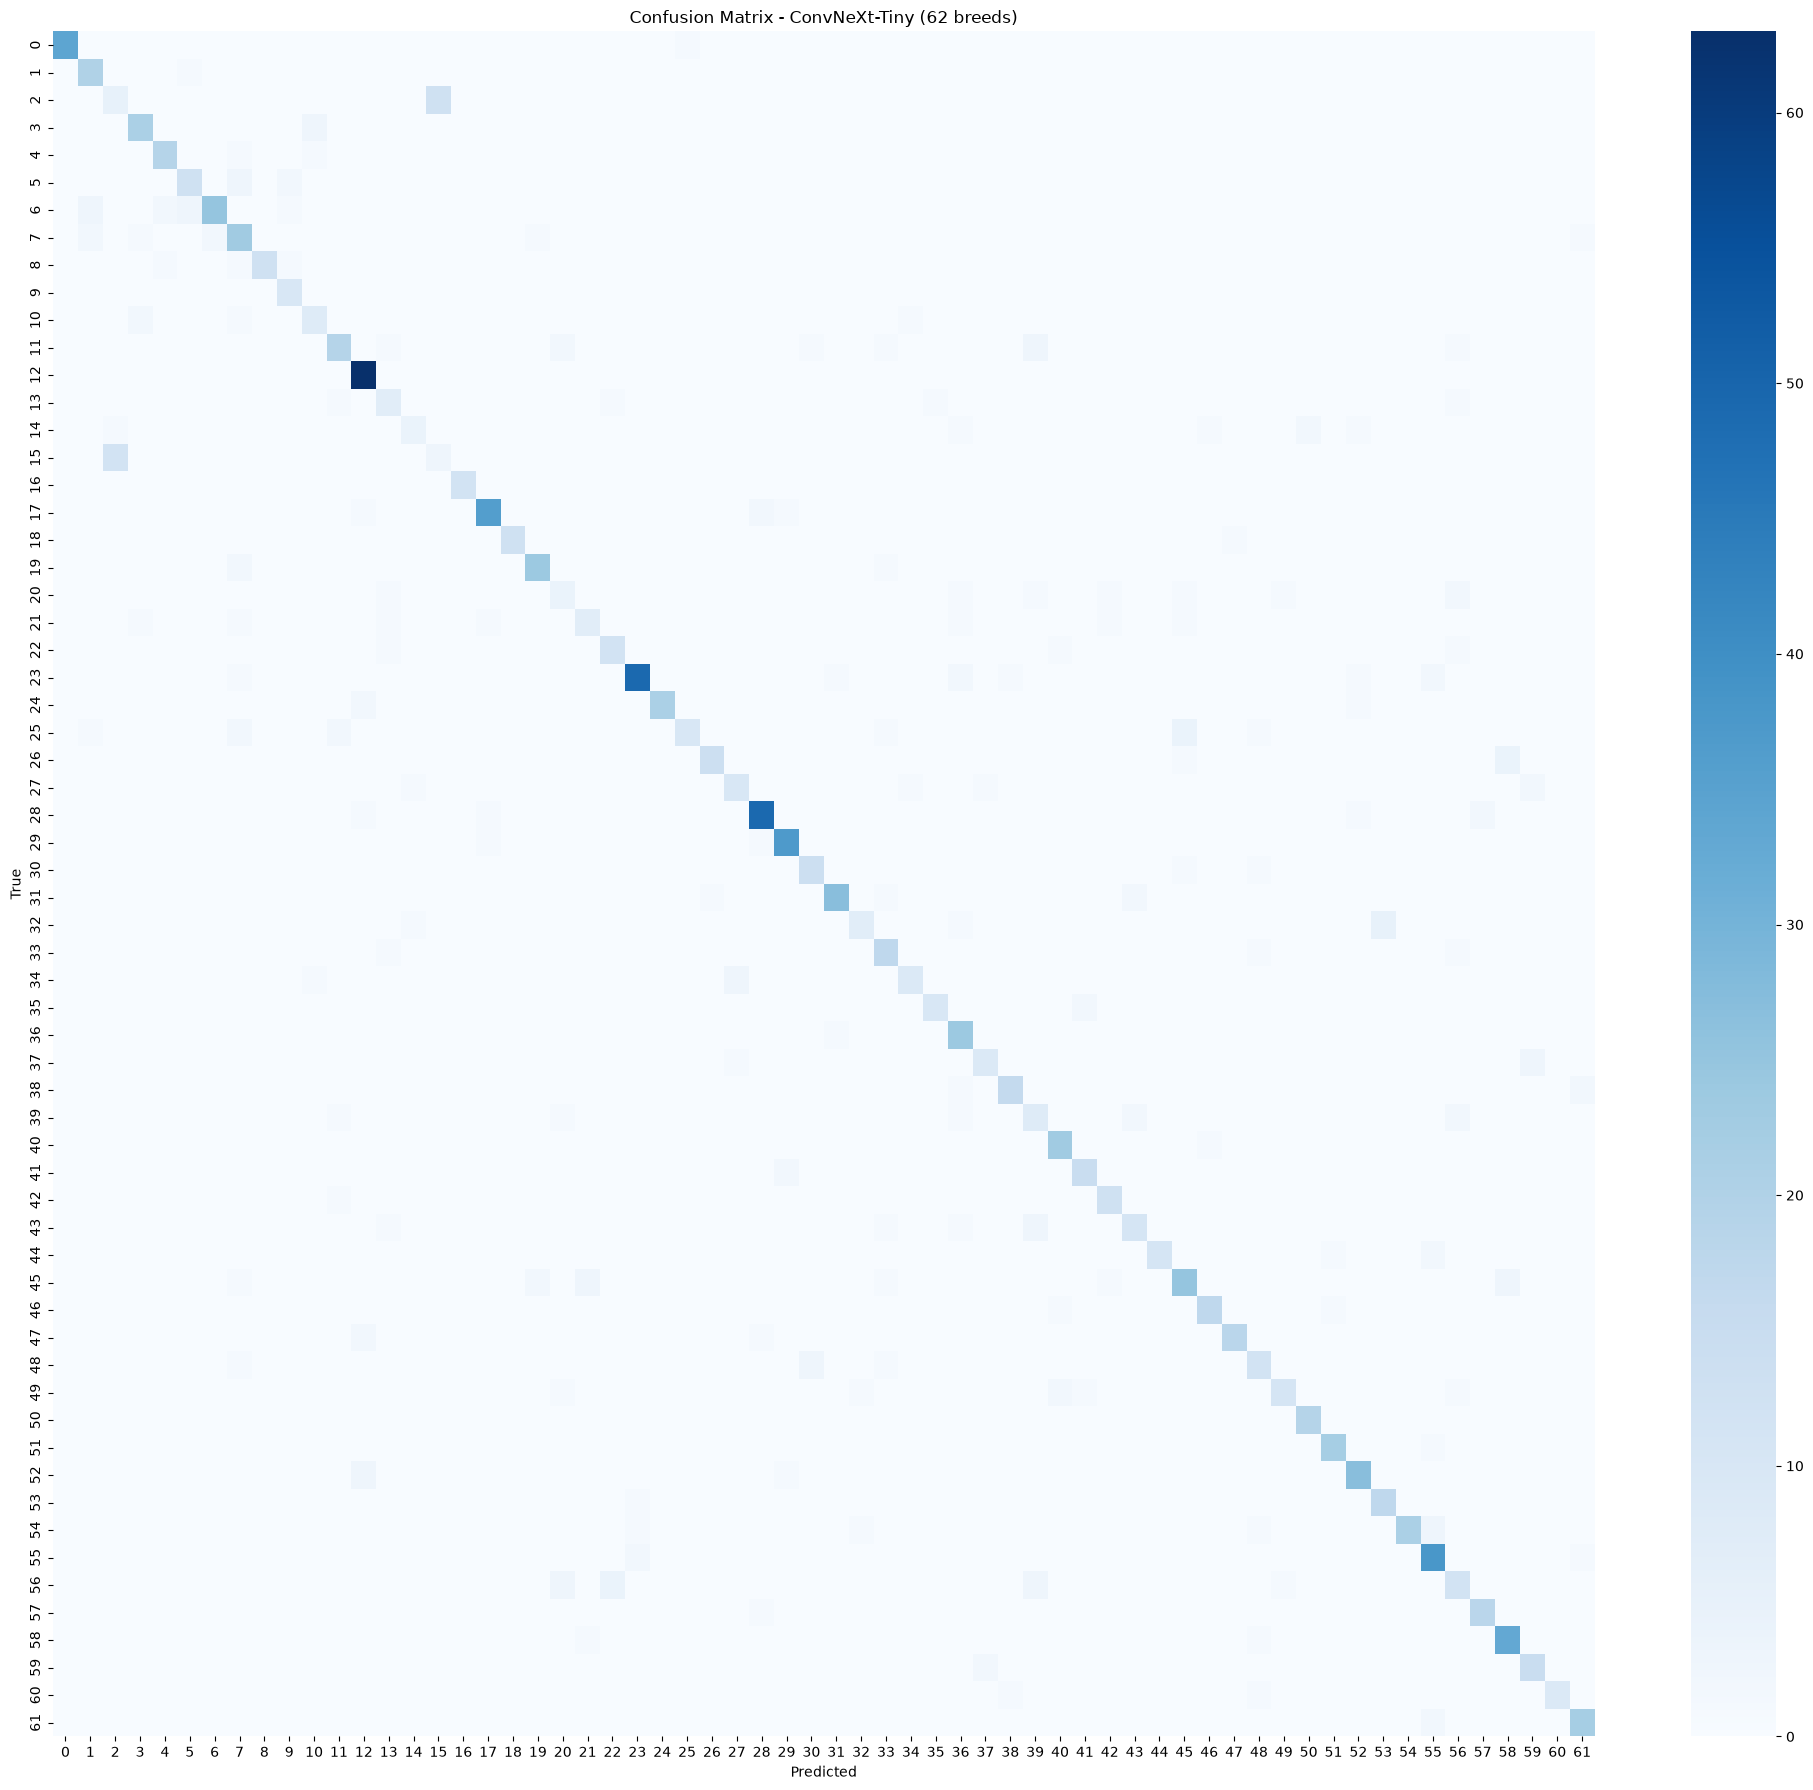


Saved: classification_report.csv, confusion_matrix.png


In [38]:
# ---- 6g. Confusion matrix (saved as image, too large to display well for 62 classes) ----
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Confusion Matrix - ConvNeXt-Tiny (62 breeds)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nSaved: classification_report.csv, confusion_matrix.png")

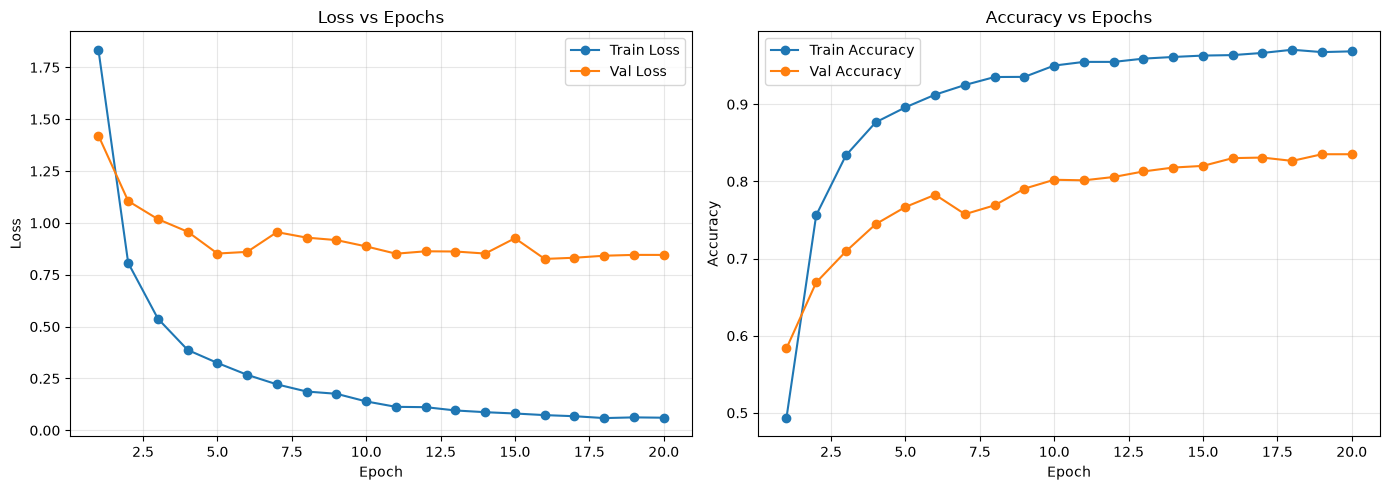

Saved: training_curves.png


In [40]:
# ================================
# Plot Training History (Loss & Accuracy curves)
# ================================

import json
import matplotlib.pyplot as plt

with open("training_history.json") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ---- Loss curve ----
axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs, history["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Accuracy curve ----
axes[1].plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", marker="o")
axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("Saved: training_curves.png")